# Workshop 5: Working with Real Public Data  
## APIs and Messy Data

**Applied Data Science Workshop Series**

In this workshop, you will learn how to:

- Understand what APIs are
- Retrieve data from a public API
- Convert API responses into a DataFrame
- Remove aggregate regions from World Bank data
- Keep country-level records only
- Identify missing values
- Clean and prepare real-world public data
- Create basic visualizations

# 1. Key Libraries Used

## Pandas
Used for working with tabular data.

## Requests
Used to retrieve data from web APIs.

## Matplotlib
Used for charts and visualizations.

## Seaborn
Used to create clean statistical charts.

## JSON
API responses are often returned in JSON format. Python reads JSON-like structures as dictionaries and lists.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# Workshop colour palette — navy, gold, ice blue
NAVY  = "#1E2761"
GOLD  = "#C9A84C"
ICE   = "#CADCFC"
sns.set_palette([NAVY, GOLD, ICE])
print("Setup complete.")

Setup complete.


# 2. What is an API?

An **API**, or Application Programming Interface, allows one system to request data from another system.

Public data APIs allow analysts to access datasets from sources such as:

- World Bank
- U.S. Census
- WHO
- OpenStreetMap

In this notebook, we will use the World Bank API as an example.

## Exploring World Bank Indicators

In [4]:
indicator_list_url = "https://api.worldbank.org/v2/indicator?format=json&per_page=2000"

indicator_list_response = requests.get(indicator_list_url)

print("Status code:", indicator_list_response.status_code)

if indicator_list_response.status_code != 200:
    raise Exception(f"API call failed with status code: {indicator_list_response.status_code}. Check your connection and try again.")

indicator_list_data = indicator_list_response.json()
print("Total indicators retrieved:", indicator_list_data[0]["total"])

Status code: 200
Total indicators retrieved: 29544


In [ ]:
# Extract indicator details and create a DataFrame
indicators_df = pd.DataFrame([
    {
        "indicator_id": item["id"],
        "indicator_name": item["name"],
        "source_organization": item["sourceOrganization"]
    }
    for item in indicator_list_data[1]
])

print("First 5 indicators:")
display(indicators_df.head())

First 5 indicators:


,indicator_id,indicator_name,source_organization
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day),LAC Equity Lab tabulations of SEDLAC (CEDLAS a...
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day),LAC Equity Lab tabulations of SEDLAC (CEDLAS a...
2,1.0.HCount.Mid10to50,Middle Class ($10-50 a day) Headcount,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National,LAC Equity Lab tabulations of data from Nation...
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day),LAC Equity Lab tabulations of SEDLAC (CEDLAS a...


You can use the `indicator_id` column to search for specific indicators or explore more data by modifying the `indicator_url` earlier in the notebook.

# 3. Workshop Indicator

For this workshop, we will use the World Bank indicator:

## Fixed broadband subscriptions per 100 people

Indicator code:

`IT.NET.BBND.P2`

This is useful for a digital equity workshop because broadband subscriptions are directly connected to digital infrastructure and access.

# 4. Retrieve Indicator Data from the World Bank API

This API call retrieves broadband subscription data for all available countries and years.

Important: The World Bank API also returns aggregate regions and income groups, so we will clean those out later.

In [ ]:
indicator_url = "https://api.worldbank.org/v2/country/all/indicator/IT.NET.BBND.P2?format=json&per_page=20000"

indicator_response = requests.get(indicator_url)

print("Status code:", indicator_response.status_code)

if indicator_response.status_code != 200:
    raise Exception(f"API call failed with status code: {indicator_response.status_code}. Check your connection and try again.")

indicator_data = indicator_response.json()
print("Records retrieved:", indicator_data[0]["total"])

Status code: 200
Records retrieved: 17556


# 5. Inspect the API Response

For this World Bank endpoint:

- `indicator_data[0]` contains **metadata** (total pages, record count, etc.)
- `indicator_data[1]` contains the **actual records** — a list of dictionaries

Each record looks like this:

```json
{
  "country": {"value": "Jamaica"},
  "countryiso3code": "JAM",
  "date": "2022",
  "value": 15.2
}
```

Notice the **nested structure** — `country` is itself a dictionary. This is why we cannot simply call `pd.read_csv()`. We must extract each field manually when building the DataFrame.

In [ ]:
indicator_data[0]

{'page': 1,
 'pages': 1,
 'per_page': 20000,
 'total': 17556,
 'sourceid': '2',
 'lastupdated': '2026-04-08'}

In [ ]:
records = indicator_data[1]

records[0]

{'indicator': {'id': 'IT.NET.BBND.P2',
  'value': 'Fixed broadband subscriptions (per 100 people)'},
 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
 'countryiso3code': 'AFE',
 'date': '2025',
 'value': 1.41,
 'unit': '',
 'obs_status': '',
 'decimal': 2}

# 6. Convert Indicator Records to a DataFrame

We extract:

- Country name
- Country code
- Year
- Fixed broadband subscriptions per 100 people

In [ ]:
api_df = pd.DataFrame([
    {
        "country": item["country"]["value"],
        "country_code": item["countryiso3code"],
        "year": item["date"],
        "broadband_subscriptions": item["value"]
    }
    for item in records
])

api_df.head()

,country,country_code,year,broadband_subscriptions
0,Africa Eastern and Southern,AFE,2025,1.41
1,Africa Eastern and Southern,AFE,2024,1.03
2,Africa Eastern and Southern,AFE,2023,0.78
3,Africa Eastern and Southern,AFE,2022,0.67
4,Africa Eastern and Southern,AFE,2021,0.62


# 7. Why Aggregates Must Be Removed

World Bank data often includes rows that are not actual countries.

Examples include:

- World
- High income
- Low income
- Europe & Central Asia
- Latin America & Caribbean

These are aggregates. If we mix them with countries, our analysis becomes misleading.

A simple filter like `country_code.str.len() == 3` is not enough because many aggregates also have 3-letter codes.

The correct approach is to retrieve World Bank country metadata and remove rows where the region is listed as **Aggregates**.

# 8. Retrieve Country Metadata

The country metadata endpoint includes region and income information for each World Bank country code.

Rows with `region = Aggregates` are not individual countries.

In [ ]:
country_url = "https://api.worldbank.org/v2/country?format=json&per_page=400"

country_response = requests.get(country_url)

print("Status code:", country_response.status_code)

country_data = country_response.json()

Status code: 200


In [ ]:
country_records = country_data[1]

country_meta = pd.DataFrame([
    {
        "country_meta_name": item["name"],
        "country_code": item["id"],
        "region": item["region"]["value"],
        "income_level": item["incomeLevel"]["value"]
    }
    for item in country_records
])

country_meta.head()

,country_meta_name,country_code,region,income_level
0,Aruba,ABW,Latin America & Caribbean,High income
1,Africa Eastern and Southern,AFE,Aggregates,Aggregates
2,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,Africa,AFR,Aggregates,Aggregates
4,Africa Western and Central,AFW,Aggregates,Aggregates


# 9. Remove Aggregates and Keep Countries Only

We keep only metadata records where:

`region != "Aggregates"`

Then we join the indicator data to this filtered country list.

This keeps actual country-level records only.

In [ ]:
countries_only = country_meta[
    country_meta["region"] != "Aggregates"
].copy()

api_country_df = api_df.merge(
    countries_only[["country_code", "country_meta_name", "region", "income_level"]],
    on="country_code",
    how="inner"
)

api_country_df.head()

,country,country_code,year,broadband_subscriptions,country_meta_name,region,income_level
0,Afghanistan,AFG,2025,NaN,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,Afghanistan,AFG,2024,NaN,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
2,Afghanistan,AFG,2023,0.080087,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,Afghanistan,AFG,2022,0.079630,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
4,Afghanistan,AFG,2021,0.066424,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income


# 10. Verify Aggregates Were Removed

This is an important validation step.

If the cleaning worked, the `region` column should show actual geographic regions, not `Aggregates`.

In [ ]:
# Validation: confirm aggregates were removed and the join worked correctly
print(f"Countries kept:   {api_country_df['country'].nunique()}")
print(f"Total rows:       {api_country_df.shape[0]}")
print(f"Years covered:    {sorted(api_country_df['year'].unique())[:5]} ... {sorted(api_country_df['year'].unique())[-3:]}")
print(f"Regions present:  {api_country_df['region'].nunique()} unique regions")
print(f"\nExpected: ~210–220 entries (includes territories and special regions)")

Countries kept:   217
Total rows:       14322
Years covered:    ['1960', '1961', '1962', '1963', '1964'] ... ['2023', '2024', '2025']
Regions present:  7 unique regions

Expected: ~210–220 entries (includes territories and special regions)


In [ ]:
api_country_df["region"].unique()

array(['Middle East, North Africa, Afghanistan & Pakistan',
       'Europe & Central Asia', 'East Asia & Pacific',
       'Sub-Saharan Africa ', 'Latin America & Caribbean ', 'South Asia',
       'North America'], dtype=object)

In [ ]:
api_country_df[api_country_df["region"] == "Aggregates"]

,country,country_code,year,broadband_subscriptions,country_meta_name,region,income_level


# 11. Review Dataset Structure

Now inspect the cleaned country-level dataset.

In [ ]:
api_country_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14322 entries, 0 to 14321
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  14322 non-null  object 
 1   country_code             14322 non-null  object 
 2   year                     14322 non-null  object 
 3   broadband_subscriptions  4330 non-null   float64
 4   country_meta_name        14322 non-null  object 
 5   region                   14322 non-null  object 
 6   income_level             14322 non-null  object 
dtypes: float64(1), object(6)
memory usage: 783.4+ KB


In [ ]:
api_country_df.describe(include="all")

,country,country_code,year,broadband_subscriptions,country_meta_name,region,income_level
count,14322,14322,14322,4330.000000,14322,14322,14322
unique,217,217,66,NaN,217,7,5
top,Afghanistan,AFG,2025,NaN,Afghanistan,Europe & Central Asia,High income
freq,66,66,217,NaN,66,3828,5676
mean,NaN,NaN,NaN,11.499388,NaN,NaN,NaN
std,NaN,NaN,NaN,13.651377,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.353829,NaN,NaN,NaN
50%,NaN,NaN,NaN,4.694005,NaN,NaN,NaN
75%,NaN,NaN,NaN,20.672830,NaN,NaN,NaN


# 12. Clean Year and Missing Values

We will:

1. Convert `year` to numeric
2. Drop rows with missing broadband subscription values
3. Keep recent years for a more focused analysis

In [ ]:
clean_api_df = api_country_df.copy()

clean_api_df["year"] = pd.to_numeric(clean_api_df["year"], errors="coerce")

clean_api_df = clean_api_df.dropna(
    subset=["year", "broadband_subscriptions"]
)
print(clean_api_df.shape)

clean_api_df.head()

(4330, 7)


,country,country_code,year,broadband_subscriptions,country_meta_name,region,income_level
2,Afghanistan,AFG,2023,0.080087,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,Afghanistan,AFG,2022,0.079630,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
4,Afghanistan,AFG,2021,0.066424,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
5,Afghanistan,AFG,2020,0.068008,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
6,Afghanistan,AFG,2019,0.051994,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income


# 13. Check Missing Values After Cleaning

In [ ]:
clean_api_df.isna().sum()

,0
country,0
country_code,0
year,0
broadband_subscriptions,0
country_meta_name,0
region,0
income_level,0


# 14. Filter to Recent Years

For this workshop, we focus on data from 2020 onward.

In [ ]:
recent_df = clean_api_df[
    clean_api_df["year"] >= 2020
].copy()


print("Rows:", recent_df.shape[0])
print("Unique countries:", recent_df["country"].nunique())
print("Years:", [int(y) for y in sorted(recent_df["year"].unique())])

recent_df.head()

Rows: 931
Unique countries: 208
Years: [2020, 2021, 2022, 2023, 2024]


,country,country_code,year,broadband_subscriptions,country_meta_name,region,income_level
2,Afghanistan,AFG,2023,0.080087,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,Afghanistan,AFG,2022,0.079630,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
4,Afghanistan,AFG,2021,0.066424,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
5,Afghanistan,AFG,2020,0.068008,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
67,Albania,ALB,2024,24.881571,Albania,Europe & Central Asia,Upper middle income


# 15. Select the Most Recent Year Available for Each Country

Some countries may not report every year.

Instead of forcing a single year and losing many countries, we can keep the most recent available record for each country.

In [ ]:
latest_country_df = (
    recent_df
    .sort_values(["country", "year"])
    .groupby("country", as_index=False)
    .last()
    .copy()
)

latest_country_df.head()

,country,country_code,year,broadband_subscriptions,country_meta_name,region,income_level
0,Afghanistan,AFG,2023,0.080087,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,Albania,ALB,2024,24.881571,Albania,Europe & Central Asia,Upper middle income
2,Algeria,DZA,2024,13.317309,Algeria,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income
3,Andorra,AND,2024,52.355439,Andorra,Europe & Central Asia,High income
4,Angola,AGO,2024,0.362845,Angola,Sub-Saharan Africa,Lower middle income


In [ ]:
print("Rows:", latest_country_df.shape[0])
print("Unique countries:", latest_country_df["country"].nunique())

latest_country_df[["country", "country_code", "year", "region", "income_level", "broadband_subscriptions"]].head()

Rows: 208
Unique countries: 208


,country,country_code,year,region,income_level,broadband_subscriptions
0,Afghanistan,AFG,2023,"Middle East, North Africa, Afghanistan & Pakistan",Low income,0.080087
1,Albania,ALB,2024,Europe & Central Asia,Upper middle income,24.881571
2,Algeria,DZA,2024,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,13.317309
3,Andorra,AND,2024,Europe & Central Asia,High income,52.355439
4,Angola,AGO,2024,Sub-Saharan Africa,Lower middle income,0.362845


# 16. Visualization: Distribution of Broadband Subscriptions

This chart shows the distribution of fixed broadband subscriptions per 100 people across countries.

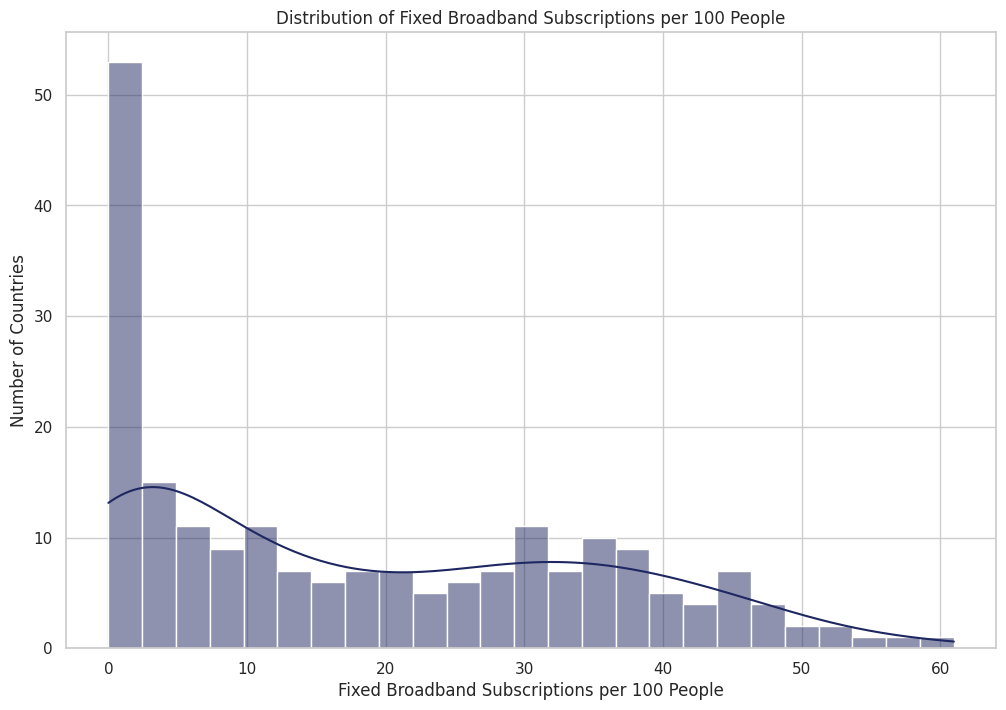

In [ ]:
sns.histplot(
    data=latest_country_df,
    x="broadband_subscriptions",
    bins=25,
    kde=True
)

plt.title("Distribution of Fixed Broadband Subscriptions per 100 People")
plt.xlabel("Fixed Broadband Subscriptions per 100 People")
plt.ylabel("Number of Countries")
plt.show()

# 17. Compare Broadband Access by Income Level

This chart helps connect public data to digital equity.

We compare broadband subscription levels across income groups.

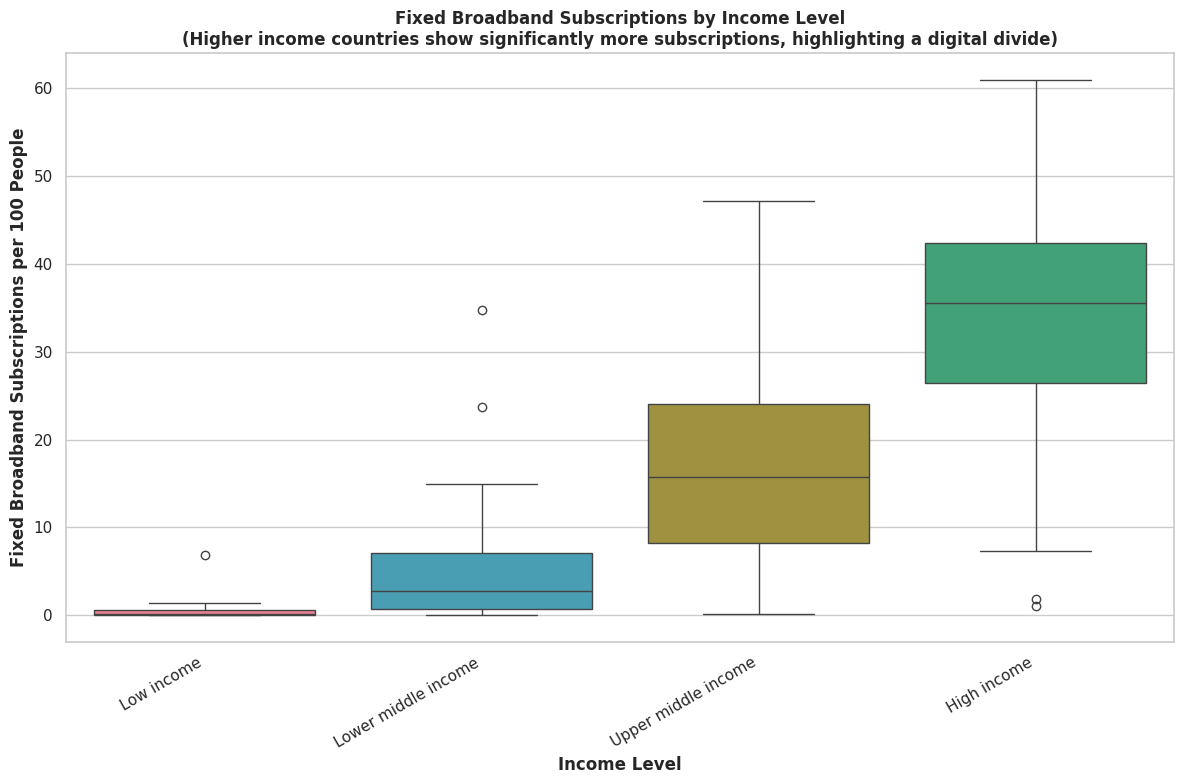

In [ ]:
income_order = [
    "Low income",
    "Lower middle income",
    "Upper middle income",
    "High income"
]

sns.boxplot(
    data=latest_country_df,
    x="income_level",
    y="broadband_subscriptions",
    hue="income_level",
    order=[x for x in income_order if x in latest_country_df["income_level"].unique()],
    legend=False
)

plt.title("Fixed Broadband Subscriptions by Income Level\n(Higher income countries show significantly more subscriptions, highlighting a digital divide)", fontweight='bold')
plt.xlabel("Income Level", fontweight='bold')
plt.ylabel("Fixed Broadband Subscriptions per 100 People", fontweight='bold')
plt.xticks(rotation=30, ha="right")
plt.tight_layout() # Adjust layout to prevent labels/title from being cut off
plt.show()

# Reflection: What Do You See?

Before continuing, take 2 minutes to write your own observations.

**Look at the boxplot above and answer:**

1. Which income group has the highest median broadband access?
2. Which group has the widest spread of values — and what might that mean?
3. Where do you see the clearest evidence of a digital divide?

*Write your observations in the cell below, then continue to compare with the summary.*

In [ ]:
# Write your observations here as comments or a print statement
# Example:
# print("I notice that high income countries have a median of approximately X...")

<details>
<summary>▶ Show suggested insights</summary>

- **Clear Disparity**: Higher-income countries consistently show more fixed broadband subscriptions per 100 people.
- **High Income**: Highest median and widest spread — many countries above 50 per 100 people.
- **Low Income**: Very low median, narrow spread, concentrated near zero — significant digital divide.
- **Gradual Increase**: A clear stepwise increase from low → lower middle → upper middle → high income.
- **Policy implication**: Broadband access correlates strongly with income level, suggesting infrastructure investment gaps in lower-income countries.

</details>

# 18. Top 10 Countries by Fixed Broadband Subscriptions

This gives a quick comparison of countries with the highest reported broadband subscription levels.

In [ ]:
top10 = latest_country_df.sort_values(
    by="broadband_subscriptions",
    ascending=False
).head(10)

top10[["country", "year", "region", "income_level", "broadband_subscriptions"]]

,country,year,region,income_level,broadband_subscriptions
4953,Gibraltar,2022,Europe & Central Asia,High income,60.974767
2379,Cayman Islands,2022,Latin America & Caribbean,High income,56.360436
8581,Monaco,2024,Europe & Central Asia,High income,55.678082
265,Andorra,2024,Europe & Central Asia,High income,52.355439
1387,Bermuda,2024,North America,High income,51.302680
7525,Liechtenstein,2024,Europe & Central Asia,High income,50.005016
4489,France,2024,Europe & Central Asia,High income,48.925198
6865,"Korea, Rep.",2024,East Asia & Pacific,High income,47.801497
2707,China,2024,East Asia & Pacific,Upper middle income,47.193395
12409,Switzerland,2024,Europe & Central Asia,High income,47.019782


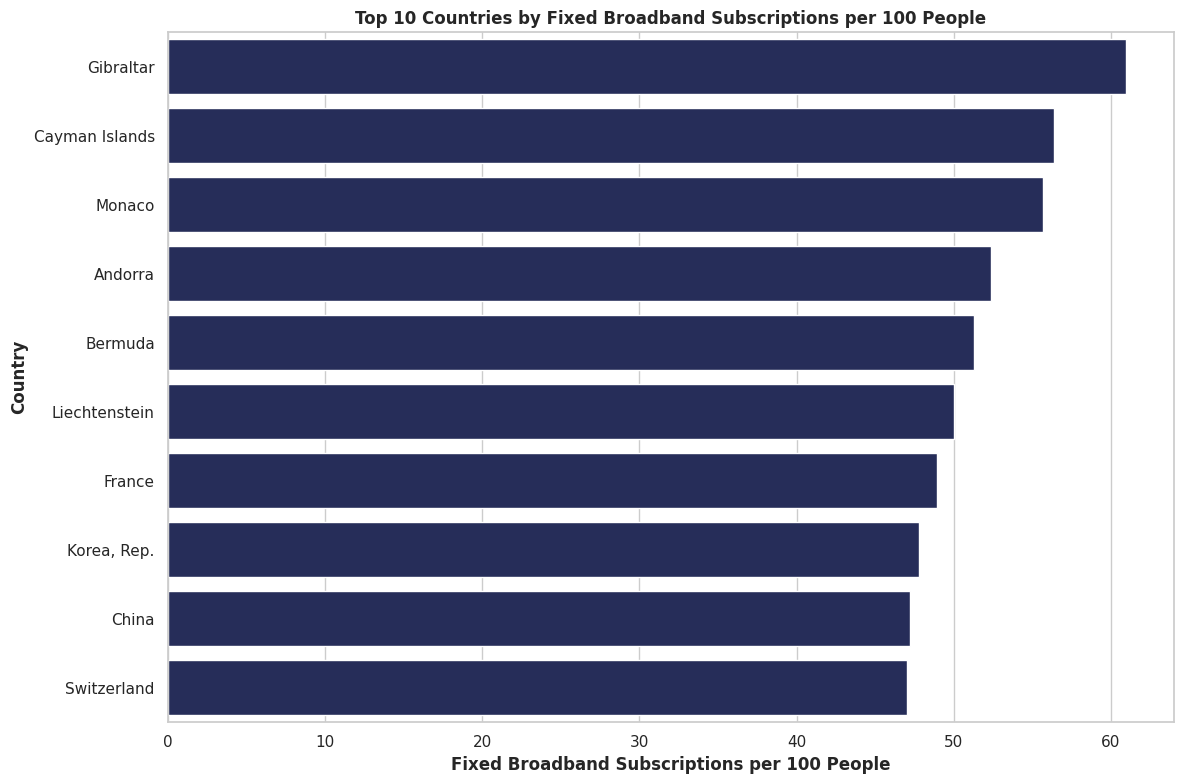

In [ ]:
sns.barplot(
    data=top10,
    x="broadband_subscriptions",
    y="country",
    color=NAVY
)

plt.title("Top 10 Countries by Fixed Broadband Subscriptions per 100 People", fontweight = "bold")
plt.xlabel("Fixed Broadband Subscriptions per 100 People", fontweight = "bold")
plt.ylabel("Country", fontweight = "bold")
plt.tight_layout()
plt.show()

# 19. Student Activity

Choose one of the following:

1. Identify the bottom 10 countries by fixed broadband subscriptions.
2. Compare broadband subscriptions by region.
3. Compare broadband subscriptions by income level.
4. Write a 3-sentence insight summary for a non-technical audience.

In [ ]:
# ── Student Work Area ──────────────────────────────────────────────────────────
# Choose ONE of the four activities from the instructions above.
# Write your code below.
#
# Suggested variables to work with:
#   latest_country_df  — one row per country, most recent year
#   Columns: country, year, region, income_level, broadband_subscriptions
#
# Remember to:
#   1. Create your chart with a descriptive title and axis labels
#   2. Write a 3 sentence insight below your chart
# ──────────────────────────────────────────────────────────────────────────────


# 20. Reflection Questions

Answer the following:

1. Why did we need to remove aggregate regions?
2. Why was `country_code.str.len() == 3` not enough?
3. What did the country metadata add to the analysis?
4. What patterns do you see by income level?
5. How could this dataset support a digital equity research question?

# Key Takeaways

- APIs provide direct access to public datasets.
- Public data often includes aggregates that must be removed.
- Metadata is essential for correctly interpreting rows.
- Country-level analysis should not mix countries with regional or income aggregates.
- Cleaning and validation are essential before visualization or modeling.

## Further Student Activities / Extensions

Students can extend this notebook in many ways, including:

1.  **Analyze Trends Over Time for Specific Countries or Regions:**
    *   Select 3-5 countries or regions (e.g., one from each income level or different regions).
    *   Filter the `clean_api_df` to include only these selected entities.
    *   Create a line plot showing the `broadband_subscriptions` over `year` for each selected country/region.
    *   Write a short insight summarizing the observed trends and any significant changes.

2.  **Compare Broadband Subscriptions by Region (Boxplot):**
    *   Create a boxplot similar to the income level comparison, but using the `region` column on the x-axis.
    *   Order the regions if desired (e.g., by median subscription count).
    *   Analyze which regions have the highest/lowest median subscriptions and the widest/narrowest spread.
    *   Write your insights discussing regional disparities.

3.  **Identify Outliers within Income Groups:**
    *   For one or two income groups (e.g., 'Lower middle income' and 'High income'), identify countries that are significantly above or below the median broadband subscriptions for their group.
    *   You could use statistical methods (like IQR) or simply visual inspection of the boxplot to identify these countries.
    *   Display a table of these outlier countries and propose potential reasons for their unique position.

4.  **Explore the Relationship between Year and Subscriptions:**
    *   Create a scatter plot showing `broadband_subscriptions` against `year`.
    *   Consider adding `income_level` or `region` as a `hue` or `size` parameter to see how this relationship varies.
    *   Discuss the overall trend of broadband adoption over time.

5.  **Hypothesize and Investigate External Factors:**
    *   (Advanced, requires external data) Imagine you have access to other World Bank indicators (e.g., GDP per capita, education expenditure). Formulate a hypothesis about how broadband subscriptions might correlate with one of these factors.
    *   Discuss how you would retrieve such data, merge it with the current dataset, and then visualize/analyze the correlation.

---

## Learning Objectives — Check-In

At the start of this workshop, we set eight goals. Review them and reflect on which you feel confident about.

1. ✅ Explain what an API is
2. ✅ Retrieve data from a public API
3. ✅ Convert JSON data into a usable dataset
4. ✅ Identify common data quality issues
5. ✅ Remove aggregate records
6. ✅ Validate datasets before analysis
7. ✅ Create basic exploratory visualizations
8. ✅ Document a reproducible workflow

